<a href="https://colab.research.google.com/github/Atharv-Chopade/Machine_Learning/blob/main/LinearR_house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('housing.csv')

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
from pickle import TRUE
df.rename(columns = {'median_house_value' : 'Price'} , inplace= True)

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,Price,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [ ]:
df.dropna(inplace= True)

In [ ]:
df = pd.get_dummies(df , 'ocean_proximity' , drop_first= True).astype(int)

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,Price,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122,37,41,880,129,322,126,8,452600,0,0,1,0
1,-122,37,21,7099,1106,2401,1138,8,358500,0,0,1,0
2,-122,37,52,1467,190,496,177,7,352100,0,0,1,0
3,-122,37,52,1274,235,558,219,5,341300,0,0,1,0
4,-122,37,52,1627,280,565,259,3,342200,0,0,1,0


In [ ]:
X = df.drop('Price' , axis = 1)
y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lg = LinearRegression()

In [ ]:
lg.fit(X_train , y_train)

LinearRegression()

In [ ]:
y_pred = lg.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error

In [ ]:
mean_squared_error(y_test , y_pred)

5100440496.948731

In [ ]:
root_mean_squared_error(y_test , y_pred)

71417.36831435846

In [ ]:
mean_absolute_error(y_test,y_pred)

52364.58617375083

In [ ]:
r2_score(y_test , y_pred)

0.627029391658781

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

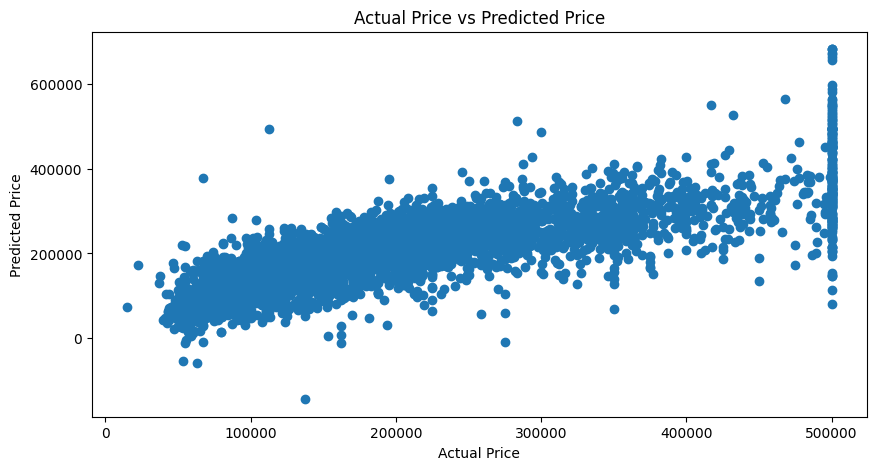

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(y_test , y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Price vs Predicted Price')
plt.show()

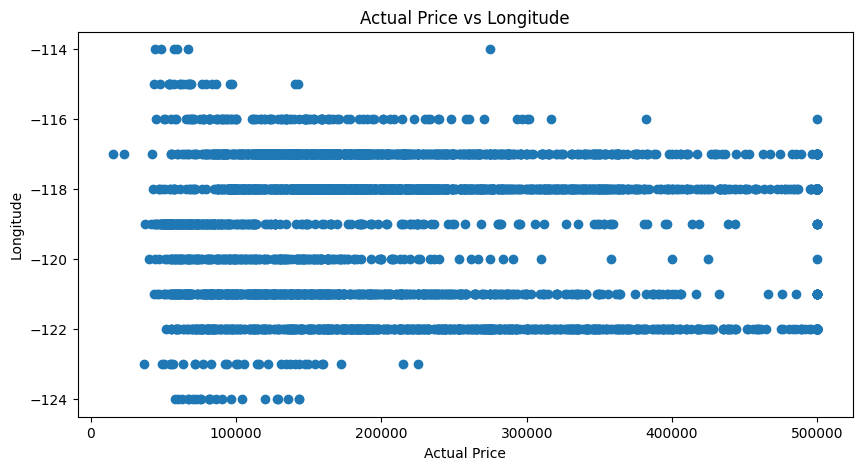

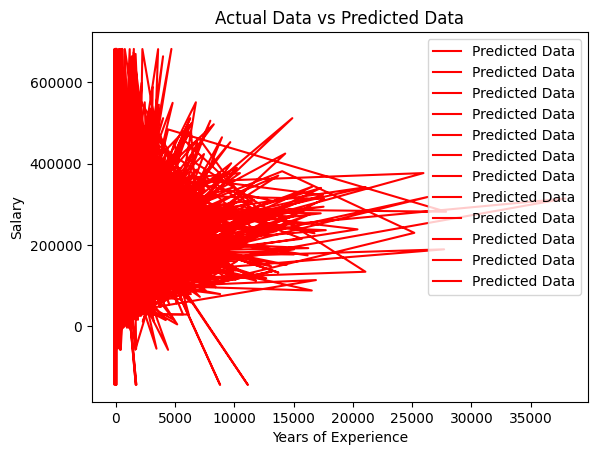

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(y_test , X_test['longitude'])
plt.xlabel('Actual Price')
plt.ylabel('Longitude')
plt.title('Actual Price vs Longitude')
plt.show()
plt.plot(X_test,y_pred, color = 'red' , label = 'Predicted Data')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Actual Data vs Predicted Data')
plt.legend()
plt.show()